In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/nbaiot-dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nbaiot-dataset/7.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/9.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/5.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/1.mirai.udp.csv
/kaggle/input/nbaiot-dataset/4.gafgyt.udp.csv
/kaggle/input/nbaiot-dataset/6.gafgyt.udp.csv
/kaggle/input/nbaiot-dataset/6.gafgyt.junk.csv
/kaggle/input/nbaiot-dataset/data_summary.csv
/kaggle/input/nbaiot-dataset/5.gafgyt.udp.csv
/kaggle/input/nbaiot-dataset/9.gafgyt.junk.csv
/kaggle/input/nbaiot-dataset/9.mirai.scan.csv
/kaggle/input/nbaiot-dataset/1.benign.csv
/kaggle/input/nbaiot-dataset/2.mirai.udpplain.csv
/kaggle/input/nbaiot-dataset/3.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/4.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/6.mirai.scan.csv
/kaggle/input/nbaiot-dataset/5.mirai.udp.csv
/kaggle/input/nbaiot-dataset/3.benign.csv
/kaggle/input/nbaiot-dataset/3.gafgyt.junk.csv
/kaggle/input/nbaiot-dataset/7.gafgyt.scan.csv
/kaggle/input/nbaiot-dataset/features.csv
/kaggle/input/nbaiot-dataset/6

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input/nbaiot-dataset'):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))

/kaggle/input/nbaiot-dataset/7.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/9.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/5.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/1.mirai.udp.csv
/kaggle/input/nbaiot-dataset/4.gafgyt.udp.csv


In [3]:
import pandas as pd
import os

DATA_PATH = "/kaggle/input/nbaiot-dataset"

files = [
    "1.benign.csv",
    "2.benign.csv",
    "3.benign.csv",
    "1.mirai.udp.csv",
    "1.mirai.syn.csv",
    "1.gafgyt.udp.csv"
]

dfs = []

for f in files:
    df = pd.read_csv(os.path.join(DATA_PATH, f))
    
    if "benign" in f:
        df["label"] = 0
    else:
        df["label"] = 1
    
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (567873, 116)


,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,label
0,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,...,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0,0
1,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,...,0.0,0.0,5.319895,344.262695,4.710446,344.262695,22.188299,0.0,0.0,0
2,1.857879,360.458980,35.789338,1.912127,360.275733,35.923972,1.969807,360.091968,35.991542,1.996939,...,0.0,0.0,6.318264,347.703087,9.034660,347.703087,81.625077,0.0,0.0,0
3,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,...,0.0,0.0,1.000000,337.000000,0.000000,337.000000,0.000000,0.0,0.0,0
4,1.680223,172.140917,18487.448750,1.793580,182.560279,18928.175300,1.925828,193.165753,19153.795810,1.992323,...,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0,0


In [4]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

2026-02-28 04:25:06.787532: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772252707.022004      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772252707.096502      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772252707.646013      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772252707.646038      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772252707.646041      24 computation_placer.cc:177] computation placer alr

In [5]:
DATA_PATH = "/kaggle/input/nbaiot-dataset"

files = [f for f in os.listdir(DATA_PATH) if f.endswith(".csv")]

print("Total CSV files found:", len(files))

df_list = []

for f in files:
    file_path = os.path.join(DATA_PATH, f)
    df = pd.read_csv(file_path)

    # Assign labels
    if "benign" in f.lower():
        df["label"] = 0
    else:
        df["label"] = 1

    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)
print("Final dataset shape:", data.shape)


Total CSV files found: 92
Final dataset shape: (7062819, 123)


In [6]:
# ===============================
# 2. LOAD DATASET (N-BaIoT)
# ===============================
DATA_PATH = "/kaggle/input/nbaiot-dataset"

files = [f for f in os.listdir(DATA_PATH) if f.endswith(".csv")]

df_list = []

for f in files:
    df = pd.read_csv(os.path.join(DATA_PATH, f))
    
    # Labeling
    if "benign" in f.lower():
        df["label"] = 0
    else:
        df["label"] = 1
    
    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)
print("Dataset shape:", data.shape)


Dataset shape: (7062819, 123)


In [7]:
# Random sampling
data = data.sample(n=500_000, random_state=42)
print(data.shape)

(500000, 123)


In [8]:
data = data.select_dtypes(include=[np.number])
print(data.shape)
data = data.fillna(0)
X = data.drop(columns=["label"])
y = data["label"]


(500000, 119)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(
    X_train[y_train == 0],  # train ONLY on benign
    X_train[y_train == 0],
    epochs=10,
    batch_size=256,
    validation_split=0.1
)

I0000 00:00:1772253021.512119      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772253021.520064      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10


I0000 00:00:1772253024.199658      69 service.cc:152] XLA service 0x7b742005f3c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772253024.199696      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772253024.199700      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772253024.551659      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


 78/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.4531

I0000 00:00:1772253025.652555      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 3.1484 - val_loss: 0.9705
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9113 - val_loss: 0.4684
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4421 - val_loss: 0.3207
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2928 - val_loss: 0.2535
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2334 - val_loss: 0.2019
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1795 - val_loss: 0.1614
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1569 - val_loss: 0.1360
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1237 - val_loss: 0.1198
Epoch 9/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1128 - val_loss: 0.1081
Epoch 10/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1061 - val_loss: 0.0974


In [12]:
X_train_r = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_r  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Build CNN-GRU model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X_train.shape[1], 1)),
    Dropout(0.3),
    
    GRU(64, return_sequences=False),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 116, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 116, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,281 (98.75 KB)

 Trainable params: 25,281 (98.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9659 - loss: 0.1395 - val_accuracy: 0.9975 - val_loss: 0.0120
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9971 - loss: 0.0137 - val_accuracy: 0.9980 - val_loss: 0.0083
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9977 - loss: 0.0098 - val_accuracy: 0.9987 - val_loss: 0.0057
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9982 - loss: 0.0079 - val_accuracy: 0.9988 - val_loss: 0.0043
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9982 - loss: 0.0070 - val_accuracy: 0.9990 - val_loss: 0.0039
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9987 - loss: 0.0051 - val_accuracy: 0.9990 - val_loss: 0.0037
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9989 - loss: 0.0046 - val_accuracy: 0.9995 - val_loss: 0.0020
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9992 - loss: 0

In [15]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
Accuracy : 0.9995
Precision: 0.9997394759123771
Recall   : 0.9997177716990143
F1-score : 0.9997286236878955
ROC-AUC  : 0.99997089868649
Confusion Matrix:
 [[ 7852    24]
 [   26 92098]]


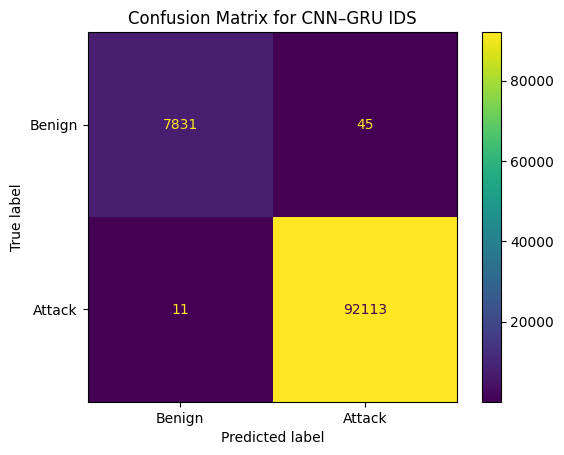

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

cm = np.array([[7831, 45],
               [11, 92113]])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Attack"]
)

disp.plot()
plt.title("Confusion Matrix for CNN–GRU IDS")
plt.show()


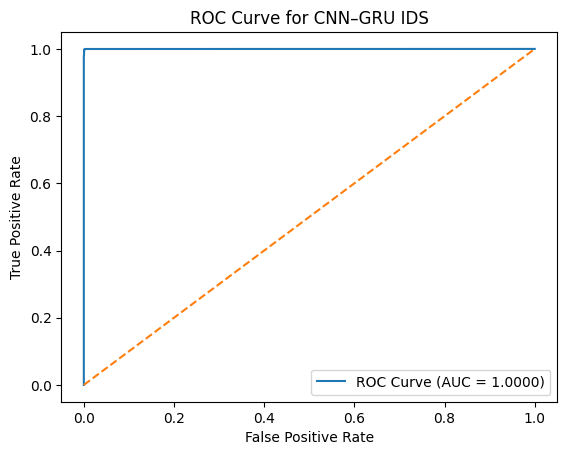

In [17]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for CNN–GRU IDS")
plt.legend(loc="lower right")
plt.show()


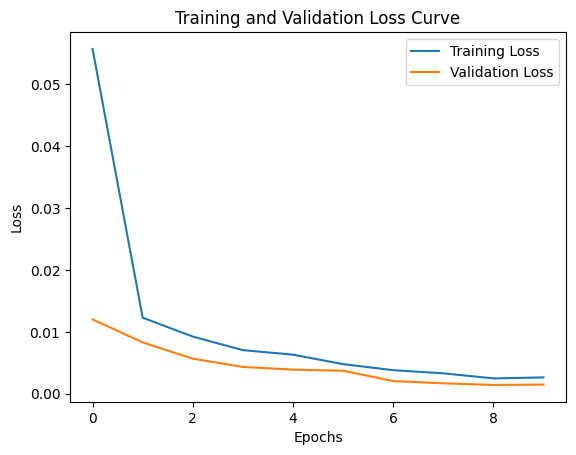

In [18]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.show()


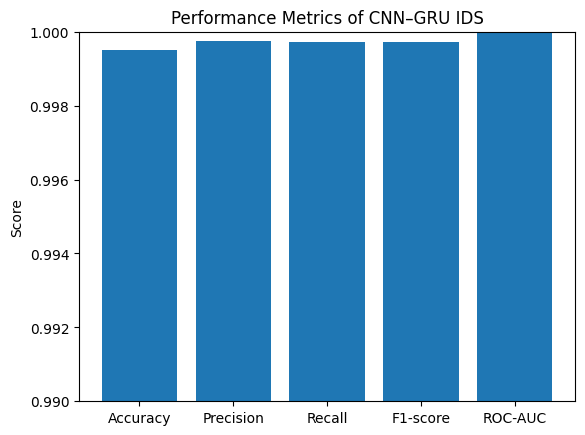

In [19]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": roc_auc
}

plt.bar(metrics.keys(), metrics.values())
plt.ylim(0.99, 1.0)
plt.ylabel("Score")
plt.title("Performance Metrics of CNN–GRU IDS")
plt.show()

In [20]:
# Use ONLY benign samples for training autoencoder
X_benign = data[data["label"] == 0].drop(columns=["label"])

# Normalize again (important)
X_benign = scaler.transform(X_benign)

print("Benign samples:", X_benign.shape)

Benign samples: (39378, 118)


In [21]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_benign.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)

decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 118)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         7,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 118)            │         7,670 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,478 (76.09 KB)

 Trainable params: 19,478 (76.09 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_ae = autoencoder.fit(
    X_benign, X_benign,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.3557 - val_loss: 0.8720
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7887 - val_loss: 0.4172
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4078 - val_loss: 0.2733
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2463 - val_loss: 0.2203
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2035 - val_loss: 0.1783
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1606 - val_loss: 0.1594
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1459 - val_loss: 0.1291
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1252 - val_loss: 0.1197
Epoch 9/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1071 - val_loss: 0.1299
Epoch 10/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1191 - val_loss: 0.0919


In [23]:
# Reconstruct all data
X_all = scaler.transform(data.drop(columns=["label"]))
X_recon = autoencoder.predict(X_all)

# Mean Squared Error
recon_error = np.mean(np.square(X_all - X_recon), axis=1)

15625/15625 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step


In [24]:
threshold = np.percentile(recon_error, 95)
print("Anomaly threshold:", threshold)

Anomaly threshold: 1.0969129628767154


In [25]:
y_ae_pred = (recon_error > threshold).astype(int)
y_true = data["label"].values


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

ae_accuracy = accuracy_score(y_true, y_ae_pred)
ae_precision = precision_score(y_true, y_ae_pred)
ae_recall = recall_score(y_true, y_ae_pred)
ae_f1 = f1_score(y_true, y_ae_pred)

print("Autoencoder Accuracy :", ae_accuracy)
print("Autoencoder Precision:", ae_precision)
print("Autoencoder Recall   :", ae_recall)
print("Autoencoder F1-score :", ae_f1)


Autoencoder Accuracy : 0.126512
Autoencoder Precision: 0.97756
Autoencoder Recall   : 0.053056519228347754
Autoencoder F1-score : 0.10065030002759348


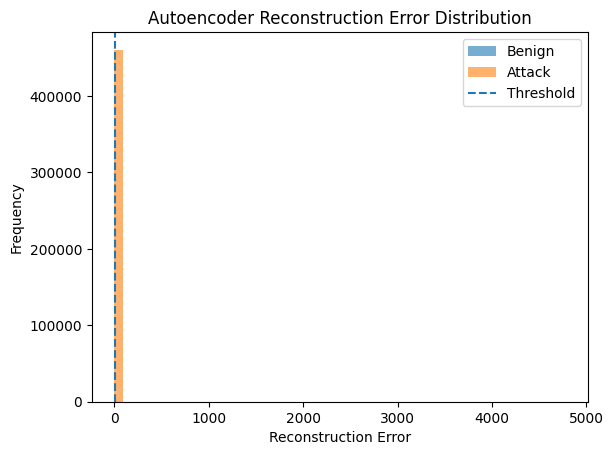

In [27]:
import matplotlib.pyplot as plt

plt.hist(recon_error[y_true == 0], bins=50, alpha=0.6, label="Benign")
plt.hist(recon_error[y_true == 1], bins=50, alpha=0.6, label="Attack")
plt.axvline(threshold, linestyle='--', label="Threshold")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Autoencoder Reconstruction Error Distribution")
plt.legend()
plt.show()


FEDREATED LEARNING

In [28]:
NUM_CLIENTS = 3

client_data = np.array_split(X_train, NUM_CLIENTS)
client_labels = np.array_split(y_train, NUM_CLIENTS)

print("Clients created:", NUM_CLIENTS)
for i in range(NUM_CLIENTS):
    print(f"Client {i+1} data shape:", client_data[i].shape)

Clients created: 3
Client 1 data shape: (133334, 118)
Client 2 data shape: (133333, 118)
Client 3 data shape: (133333, 118)


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


In [29]:
def create_cnn_gru():
    model = Sequential([
        Conv1D(64, 3, activation='relu',
               input_shape=(X_train.shape[1], 1)),
        Dropout(0.3),
        GRU(64),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


CNN_GRU

In [30]:
GLOBAL_ROUNDS = 3
LOCAL_EPOCHS = 3

global_model = create_cnn_gru()

for round_num in range(GLOBAL_ROUNDS):
    print(f"\nFederated Round {round_num + 1}")
    
    client_weights = []
    
    for i in range(NUM_CLIENTS):
        print(f"Training Client {i+1}")
        
        local_model = create_cnn_gru()
        local_model.set_weights(global_model.get_weights())
        
        local_model.fit(
            client_data[i],
            client_labels[i],
            epochs=LOCAL_EPOCHS,
            batch_size=256,
            verbose=0
        )
        
        client_weights.append(local_model.get_weights())
    
    # FedAvg
    new_weights = []
    for weights in zip(*client_weights):
        new_weights.append(np.mean(weights, axis=0))
    
    global_model.set_weights(new_weights)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Federated Round 1
Training Client 1
Training Client 2
Training Client 3

Federated Round 2
Training Client 1
Training Client 2
Training Client 3

Federated Round 3
Training Client 1
Training Client 2
Training Client 3


In [31]:
y_fl_prob = global_model.predict(X_test).ravel()
y_fl_pred = (y_fl_prob > 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

fl_accuracy = accuracy_score(y_test, y_fl_pred)
fl_precision = precision_score(y_test, y_fl_pred)
fl_recall = recall_score(y_test, y_fl_pred)
fl_f1 = f1_score(y_test, y_fl_pred)
fl_roc = roc_auc_score(y_test, y_fl_prob)

print("Federated Accuracy :", fl_accuracy)
print("Federated Precision:", fl_precision)
print("Federated Recall   :", fl_recall)
print("Federated F1-score :", fl_f1)
print("Federated ROC-AUC  :", fl_roc)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
Federated Accuracy : 0.99892
Federated Precision: 0.9996524761077324
Federated Recall   : 0.9991750249663497
Federated F1-score : 0.999413693513713
Federated ROC-AUC  : 0.9998825355766761


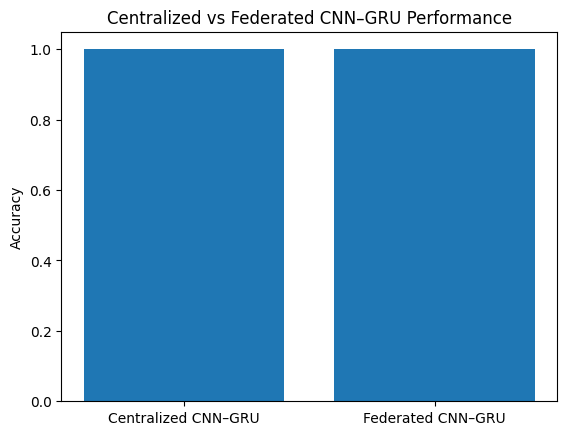

In [32]:
models = ["Centralized CNN–GRU", "Federated CNN–GRU"]
accs = [accuracy, fl_accuracy]

plt.bar(models, accs)
plt.ylabel("Accuracy")
plt.title("Centralized vs Federated CNN–GRU Performance")
plt.show()